In [1]:
import sys
import os
sys.path.append("../intervention_search")

import covasim as cv

from simulation.runner import run_evo_simulation

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


In [2]:
sim_pars = dict(
    pop_size=3000,
    pop_type='hybrid',
    pop_infected=5,
    n_days=60,
    rand_seed=1,
    beta=0.1, 
    verbose=0,    
)

evo_pars = dict(
  enable=True,
  reference="/home/jhkim/covasim_project/covasim4wastewater/docs/tutorials/sars-2-data/NC_045512_Hu-1.fasta",
  mol_clock_rate=0.000001,
  sub_model="JC",
  fitness_data_path="/home/jhkim/covasim_project/covasim4wastewater/data/nt_fitness.csv",
  store_infection_log=True,
) 

policy = dict(
    p_test=0.2,
    p_seq=0.5,
    detection_threshold=3,
    delay_pmf=[0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03],
    quiet_period=0,
)

In [3]:
sim, obs, interv, _, results = run_evo_simulation(sim_pars, evo_pars, policy)

In [4]:
from analysis.mutation_tree import build_mutation_tree
from plotting.plot_mutation_tree import plot_mutation_tree, plot_erase_mutation_tree

In [5]:
FIG_DIR = "../intervention_search/results/figures"

Policy B mutation tree: nodes=5541, edges=5540


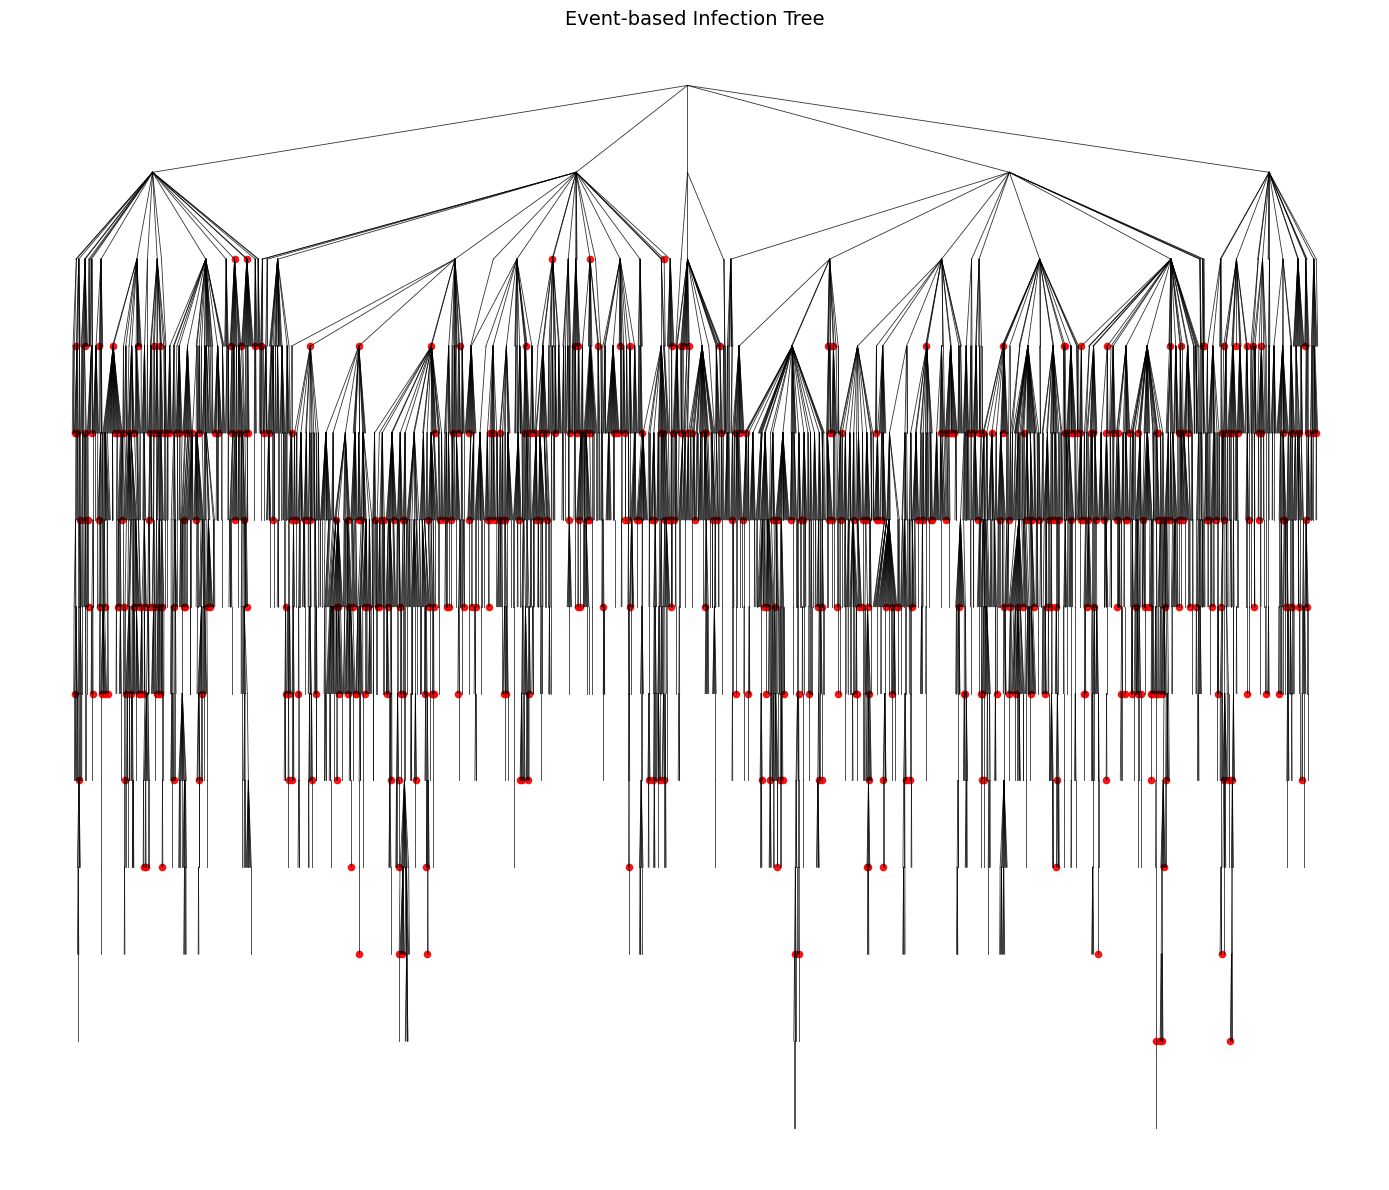

In [6]:
sequenced_agents = set()
for day_list in obs.daily_sequenced_agents:
    sequenced_agents.update(day_list)

G = build_mutation_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G.nodes)}, edges={len(G.edges)}")

plot_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_full.png"),
    detection_day=None,
    sequenced_only=False,
    collapse=False,
)



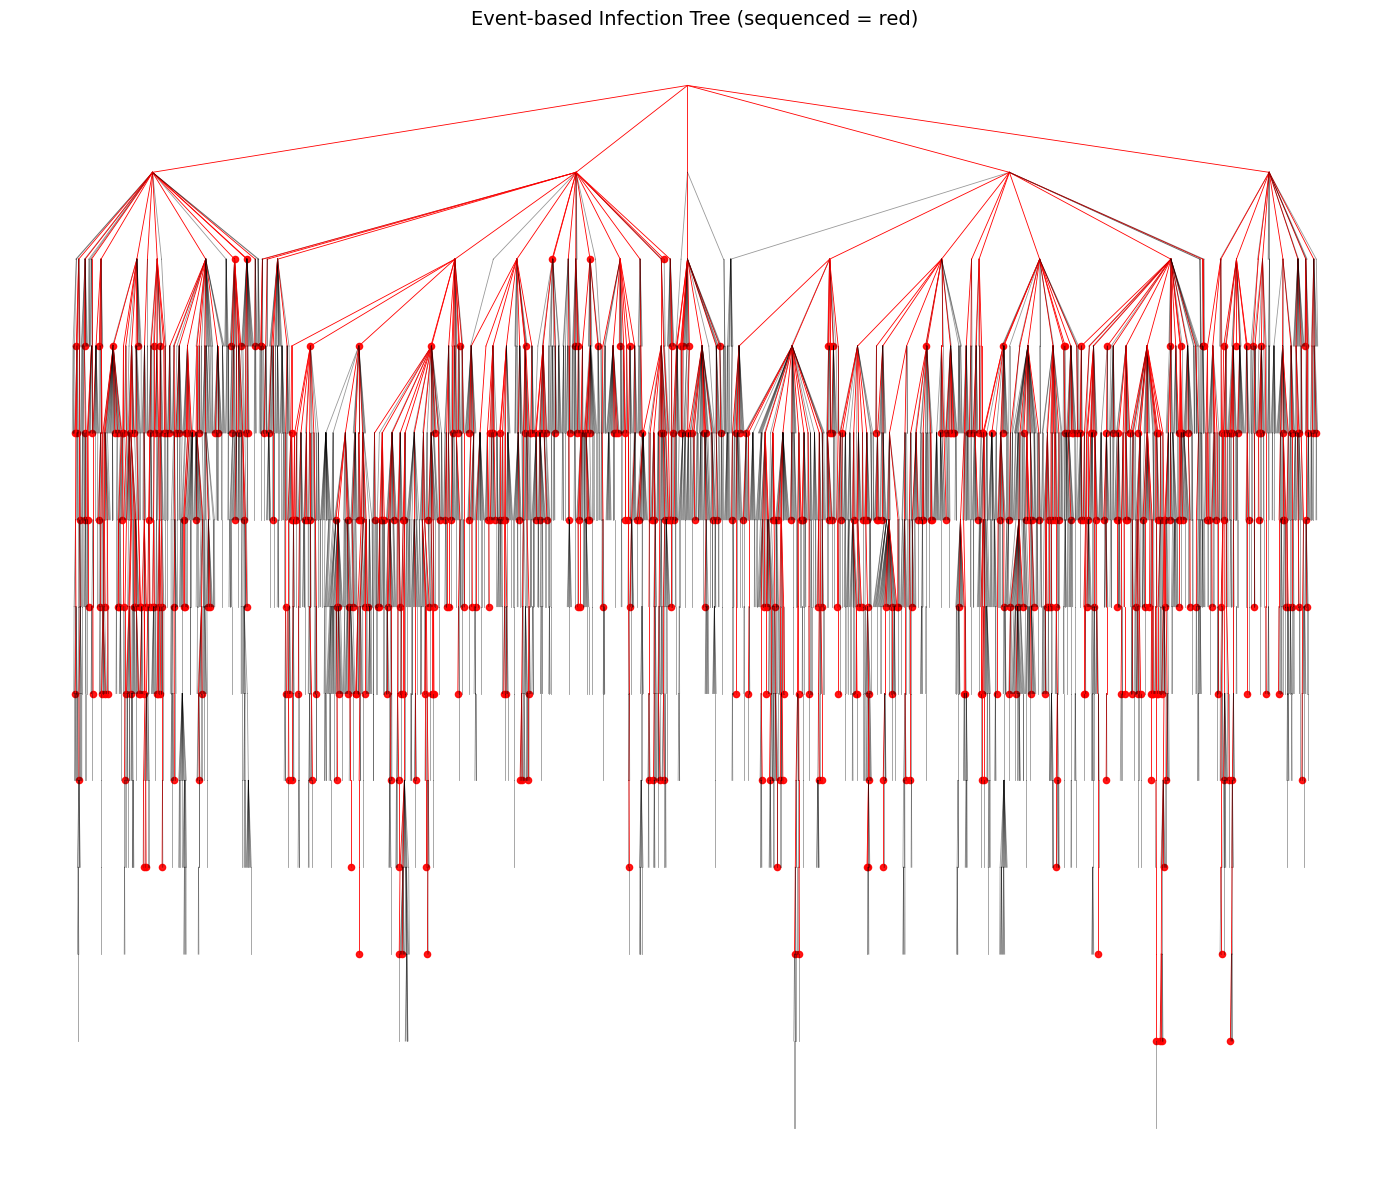

In [7]:

plot_erase_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

In [10]:
tracker = sim.sequence_tracker
ref_seq = cv.decode_sequence(tracker.reference)

all_fasta = []
sequenced_fasta = []

seq_events = []
for event in sequenced_agents:
    agent_id, date = event.split("_")
    seq_events.append((int(agent_id), int(date)))

print(f"Total sequenced events: {len(seq_events)}")

for agent_id, date in seq_events:
    entry = next(
        (e for e in sim.people.infection_log
         if int(e["target"]) == agent_id and int(e["date"]) == date),
        None
    )

    if entry is None:
        print(f"Event {agent_id}_{date}: not found in infection_log")
        continue

    hap = tracker.reconstruct_haplotype(agent_id)

    header = f">{agent_id}_{date}"
    sequenced_fasta.append(header)
    sequenced_fasta.append(hap)

fasta_str = "\n".join(sequenced_fasta)
print(fasta_str[:500]) 

with open("seq.fasta", "w") as f:
    f.write(fasta_str)

!iqtree -s seq.fasta -m JC69


Total sequenced events: 532


>1808_48
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTTAAAATCTGTGTGGCTGTCACTCGGCTGCATGCTTAGTGCACTCACGCAGTATAATTAATAACTAATTACTGTCGTTGACAGGACACGAGTAACTCGTCTATCTTCTGCAGGCTGCTTACGGTTTCGTCCGTGTTGCAGCCGATCATCAGCACATCTAGGTTTCGTCCGGGTGTGACCGAAAGGTAAGATGGAGAGCCTTGTCCCTGGTTTCAACGAGAAAACACACGTCCAACTCAGTTTGCCTGTTTTACAGGTTCGCGACGTGCTCGTACGTGGCTTTGGAGACTCCGTGGAGGAGGTCTTATCAGAGGCACGTCAACATCTTAAAGATGGCACTTGTGGCTTAGTAGAAGTTGAAAAAGGCGTTTTGCCTCAACTTGAACAGCCCTATGTGTTCATCAAACGTTCGGATG
Checkpoint (seq.fasta.ckp.gz) indicates that a previous run successfully finished
Use `-redo` option if you really want to redo the analysis and overwrite all output files.
Use `--redo-tree` option if you want to restore ModelFinder and only redo tree search.
Use `--undo` option if you want to continue previous run when changing/adding options.


In [12]:
import covasim as cv
from Bio import Phylo
import matplotlib.pyplot as plt

# 1) Covasim sequence tracker
tracker = sim.sequence_tracker
ref_seq = cv.decode_sequence(tracker.reference)

# 2) create FASTA
sequenced_fasta = []
seq_events = []

for event in sequenced_agents:
    agent_id, date = event.split("_")
    seq_events.append((int(agent_id), int(date)))

print(f"Total sequenced events: {len(seq_events)}")

for agent_id, date in seq_events:
    entry = next(
        (e for e in sim.people.infection_log
         if int(e["target"]) == agent_id and int(e["date"]) == date),
        None
    )

    if entry is None:
        print(f"Event {agent_id}_{date}: not found in infection_log")
        continue

    hap = tracker.reconstruct_haplotype(agent_id)

    header = f">{agent_id}_{date}"
    sequenced_fasta.append(header)
    sequenced_fasta.append(hap)

# 3) eliminate duplicates 
unique = {}  # seq to header
for header, seq in zip(sequenced_fasta[::2], sequenced_fasta[1::2]):
    if seq not in unique:
        unique[seq] = header

print(f"Unique sequences: {len(unique)}")

with open("seq_unique.fasta", "w") as f:
    for seq, header in unique.items():
        f.write(header + "\n")
        f.write(seq + "\n")

# 5) IQ-TREE 
!iqtree -s seq_unique.fasta -m JC69



Total sequenced events: 532
Unique sequences: 198
Checkpoint (seq_unique.fasta.ckp.gz) indicates that a previous run successfully finished
Use `-redo` option if you really want to redo the analysis and overwrite all output files.
Use `--redo-tree` option if you want to restore ModelFinder and only redo tree search.
Use `--undo` option if you want to continue previous run when changing/adding options.


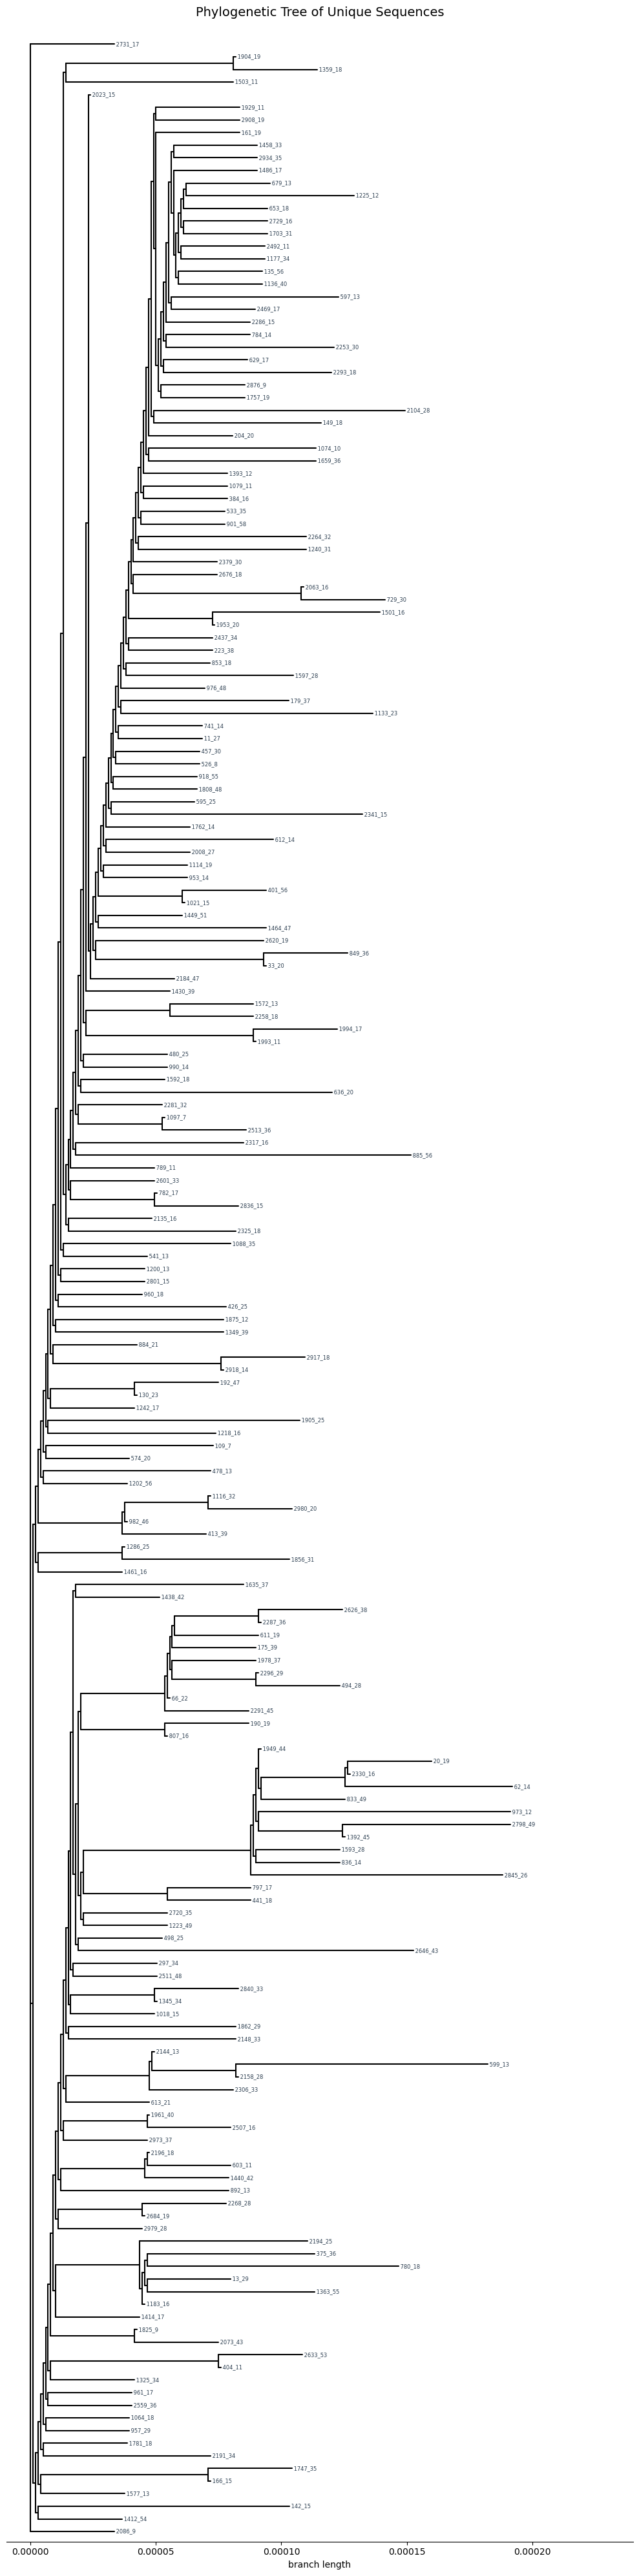

In [ ]:
from Bio import Phylo
import matplotlib.pyplot as plt


tree = Phylo.read("seq_unique.fasta.treefile", "newick")

fig = plt.figure(figsize=(10, 40))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    # label_func=lambda x: str(x) if x.name else ""
)

for text in ax.texts:
    text.set_fontsize(6)         
    text.set_color("#2c3e50")     

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_visible(False)

plt.title("Phylogenetic Tree of Unique Sequences", fontsize=14, pad=20)
plt.tight_layout()

plt.savefig("seq_tree_stretched.png", dpi=300, bbox_inches='tight')
plt.show()